<div class="jupyter-biolm-header">
    <img style="float: left; padding-right: 10px; height: 60px" src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/logo.png">
    <p>
    <br>
    <br>
    <br>
    </p>
</div>

# Explore Protein Sequence Space: Similarity, Outliers, and Property Landscapes

Use embeddings as feature vectors for similarity search, outlier detection, and landscape visualization.

<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://www.svgrepo.com/show/354202/postman-icon.svg" style="height: 15px; float: left; padding-right: 10px;"><a href="https://api.biolm.ai/">  <h5 style="margin: 0;"><b>Postman API Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/Python-logo-notext.svg/1869px-Python-logo-notext.svg.png" style="height: 15px; float: left; padding-right: 10px;"><a href="https://docs.biolm.ai/en/latest/index.html"><h5 style="margin: 0;"><b>Python SDK Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
    </tr>
</table>

<br>

---

**What you'll learn:**
- Tool 1: "Find me more like this one" — cosine similarity search
- Tool 2: "Is this sequence weird?" — outlier detection
- Tool 3: "Show me the landscape" — PCA colored by predicted property

**Requirements:**
```
pip install biolmai matplotlib numpy scikit-learn
export BIOLMAI_TOKEN=your-token-here
```

## Setup

In [1]:
import os
from biolmai.pipeline import (
    DataPipeline, DuckDBDataStore,
    ThresholdFilter, RankingFilter,
    ValidAminoAcidFilter, EmbeddingSpec,
    DiversitySamplingFilter,
)

TOKEN = os.environ.get("BIOLMAI_TOKEN", "")
if not TOKEN:
    raise EnvironmentError(
        "Set BIOLMAI_TOKEN before running.\n"
        "Get one at https://biolm.ai/ui/accounts/user-api-tokens/"
    )
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## Get embeddings for a peptide library

In [2]:
LIBRARY = [
    "GIGKFLHSAKKFGKAFVGEIMNS", "GLFDIIKKIAESF", "KLAKLAKKLAKLAK",
    "RRWWRRWWRR", "KWKLFKKI", "GIGKFLHSAK", "RLFDKIRQ",
    "GLFDIVKKVVGALGSL", "FLPLILRKIVTAL", "KWKWKWKWKW",
    "GIKKFLGSIWKFIKAFVKEIMN", "RRLCRIVVIRVCR", "RRWQWR",
    "RWRWRW", "FKRIVQRIKDFL", "KWKLFKKIPKFLHLAK",
    "GLFDIIKKIAESFLPKV", "GIGKFLHSAKKFGKAFV", "KWKLFKKIPKFLHLAKKF",
    "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES",
]

HIT_SEQUENCE = LIBRARY[0]  # our "hit" from a previous screen

ds = DuckDBDataStore("embedding_demo.duckdb")
pipeline = DataPipeline(sequences=LIBRARY, datastore=ds, verbose=True)
pipeline.add_prediction(
    "esm2-8m", action="encode",
    embedding_extractor=EmbeddingSpec(key="embeddings", layer=6),
    stage_name="embed",
)
pipeline.run()

sequence_ids = [r[0] for r in ds.conn.execute("SELECT sequence_id FROM sequences ORDER BY sequence_id").fetchall()]
sequences   = [r[0] for r in ds.conn.execute("SELECT sequence FROM sequences ORDER BY sequence_id").fetchall()]
emb_map = ds.get_embeddings_bulk(sequence_ids, model_name="esm2-8m")
mat = np.stack([emb_map[sid] for sid in sequence_ids])
print(f"Embedding matrix: {mat.shape}")

Added stage: PredictionStage('embed')

############################################################
# Pipeline: DataPipeline
# Run ID: 20260616_114359_5809885e
# Initial sequences: 20
# Streaming: ENABLED
############################################################

Execution plan: 1 level(s)
  Level 1: embed

Stage: embed
Input: 20 sequences
  Cached: 0/20
  To compute: 20
  Calling esm2-8m.encode...


  Completed: 20 sequences in 1 batches (max 5 concurrent)

StageResult(embed: in=20, out=20, cached=0, computed=20, filtered=0, time=121.4s)

############################################################
# Pipeline completed in 121.4s
# Final sequences: 20
############################################################

Embedding matrix: (20, 320)


## Tool 1: Find me more like this one

Cosine similarity on embeddings gives a ranked list of nearest neighbors.

In [3]:
hit_idx = sequences.index(HIT_SEQUENCE)
hit_vec = mat[hit_idx]
hit_norm = hit_vec / np.linalg.norm(hit_vec)

sims = []
for i, sid in enumerate(sequence_ids):
    if i == hit_idx:
        continue
    v = mat[i]
    sim = np.dot(hit_norm, v / np.linalg.norm(v))
    sims.append((sim, sequences[i]))

sims.sort(reverse=True)
print(f"Query: {HIT_SEQUENCE}\n")
print("Top 5 most similar sequences:")
for sim, seq in sims[:5]:
    print(f"  {sim:.3f}  {seq}")

Query: GIGKFLHSAKKFGKAFVGEIMNS

Top 5 most similar sequences:
  0.970  GIGKFLHSAKKFGKAFV
  0.966  GLFDIIKKIAESF
  0.959  GLFDIIKKIAESFLPKV
  0.955  FKRIVQRIKDFL
  0.953  GIGKFLHSAK


## Tool 2: Is this sequence weird?

Distance from the centroid flags outliers — contamination, misannotations, or genuinely novel variants.

In [4]:
centroid = mat.mean(axis=0)
distances = np.linalg.norm(mat - centroid, axis=1)
threshold = distances.mean() + 2 * distances.std()

print(f"Mean distance: {distances.mean():.3f}")
print(f"Outlier threshold (mean + 2σ): {threshold:.3f}\n")

outliers = [(dist, seq) for dist, seq in zip(distances, sequences) if dist > threshold]
if outliers:
    print("Outlier sequences:")
    for dist, seq in sorted(outliers, reverse=True):
        print(f"  distance={dist:.3f}  {seq}")
else:
    print("No outliers detected")

Mean distance: 2.647
Outlier threshold (mean + 2σ): 4.713

Outlier sequences:
  distance=4.937  RRWWRRWWRR


## Tool 3: Show me the landscape

PCA gives a 2D map of the library. Color by any property to see functional structure.

Added stage: PredictionStage('predict_melting_temperature')

############################################################
# Pipeline: DataPipeline
# Run ID: 20260616_114600_38fd9f30
# Initial sequences: 20
# Streaming: ENABLED
############################################################

Execution plan: 1 level(s)
  Level 1: predict_melting_temperature

Stage: predict_melting_temperature
Input: 20 sequences
  Cached: 0/20
  To compute: 20
  Calling temperature-regression.predict...


  Completed: 20 sequences in 1 batches (max 5 concurrent)

StageResult(predict_melting_temperature: in=20, out=0, cached=0, computed=20, filtered=20, time=86.5s)

############################################################
# Pipeline completed in 86.5s
# Final sequences: 0
############################################################



/var/folders/b3/g6qddbg525j0cg6_zhv46tr80000gn/T/ipykernel_96535/3497707035.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = axes[0].scatter(coords[:, 0], coords[:, 1], c=tm_values,


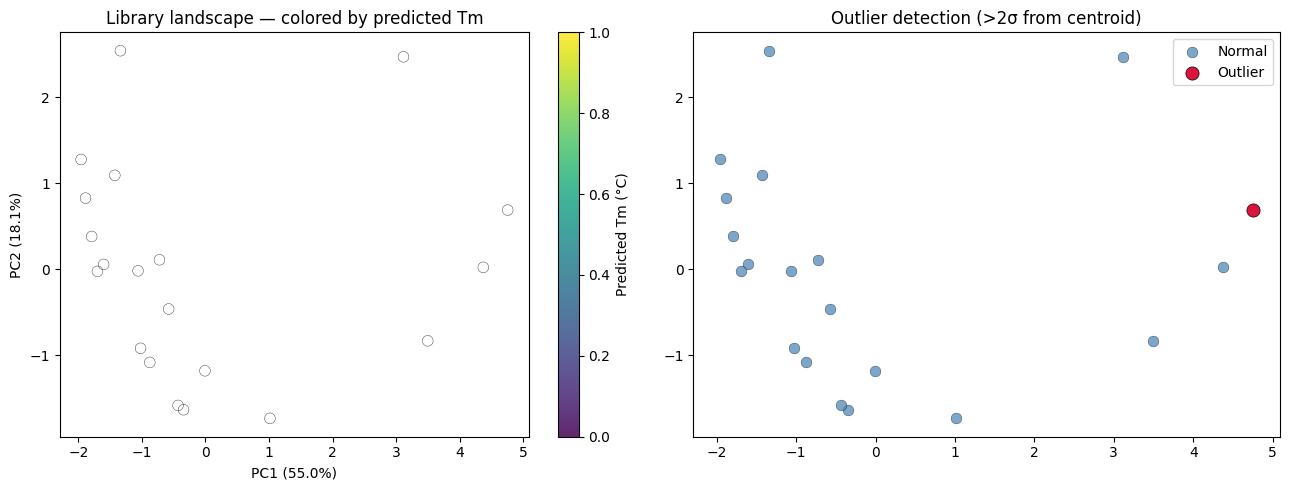

In [5]:
# First get Tm predictions for coloring
pipeline2 = DataPipeline(sequences=LIBRARY, datastore=ds, verbose=True)
pipeline2.add_prediction("temperature-regression", extractions="prediction", columns="melting_temperature")
pipeline2.run()

tm_rows = ds.conn.execute("""
    SELECT s.sequence_id, p.value AS tm
    FROM sequences s JOIN predictions p ON s.sequence_id = p.sequence_id
    WHERE p.prediction_type = 'melting_temperature'
    ORDER BY s.sequence_id
""").df()
tm_values = tm_rows["tm"].values

pca = PCA(n_components=2)
coords = pca.fit_transform(mat)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: colored by Tm
sc = axes[0].scatter(coords[:, 0], coords[:, 1], c=tm_values,
                     cmap="coolwarm", edgecolors="black", linewidth=0.3, alpha=0.85, s=60)
plt.colorbar(sc, ax=axes[0], label="Predicted Tm (°C)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("Library landscape — colored by predicted Tm")

# Right: highlight outliers
is_outlier = distances > threshold
axes[1].scatter(coords[~is_outlier, 0], coords[~is_outlier, 1],
                c="steelblue", edgecolors="black", linewidth=0.3, alpha=0.7, s=60, label="Normal")
axes[1].scatter(coords[is_outlier, 0], coords[is_outlier, 1],
                c="crimson", edgecolors="black", linewidth=0.5, s=90, zorder=5, label="Outlier")
axes[1].set_title("Outlier detection (>2σ from centroid)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Cleanup

In [6]:
ds.close()
import os; os.remove("embedding_demo.duckdb")

## Next Steps

Check out additional tutorials at [jupyter.biolm.ai](https://jupyter.biolm.ai),
or head over to our [BioLM Documentation](https://docs.biolm.ai) to explore
additional models and functionality.

#### See more use-cases and APIs on your [BioLM Console Catalog](https://biolm.ai/console/catalog/).
<br>

##### BioLM hosts deep learning models and runs inference at scale. You do the science.
<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/enzyme_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Enzyme Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/antibody_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Antibody Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/biosecurity_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Biosecurity
        </td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/single_cell_genomics_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Single-Cell Genomics
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/dna_seq_modeling_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> DNA Sequence Modelling
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/finetuning_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Finetuning
        </td>
    </tr>
</table>

#### [**Contact us**](https://biolm.ai/ui/contact-us/) to learn more.